# **XAI4Spectra**

# **Loading data**

In [1]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import kennard_stone as ks

# loading a soil spectral dataset based on X-ray fluorescence (XRF)
data_complete = pd.read_csv('XRF_databases/soil/plsda/soil.csv', sep=';') # local copy of Toledo 2022 dataset
data = data_complete.loc[:, '1':'15']

data_A = data_complete[data_complete['Class'] == 'A'].reset_index(drop=True)
data_B = data_complete[data_complete['Class'] == 'B'].reset_index(drop=True)

# splitting the data into calibration and prediction sets by kennard-stone algorithm
XA_cal, XA_pred = ks.train_test_split(data_A.loc[:, '1':'15'], test_size=0.30) # class A
XA_cal = XA_cal.reset_index(drop=True)
XA_pred = XA_pred.reset_index(drop=True)

XB_cal, XB_pred = ks.train_test_split(data_B.loc[:, '1':'15'], test_size=0.30) # class B
XB_cal = XB_cal.reset_index(drop=True)
XB_pred = XB_pred.reset_index(drop=True)

Xcalclass = pd.concat([XA_cal, XB_cal], axis=0).reset_index(drop=True) # concatenating both classes
Xpredclass = pd.concat([XA_pred, XB_pred], axis=0).reset_index(drop=True)
ycalclass = pd.Series(['A']*XA_cal.shape[0] + ['B']*XB_cal.shape[0]) # creating the target variable for calibration set
ypredclass = pd.Series(['A']*XA_pred.shape[0] + ['B']*XB_pred.shape[0]) # creating the target variable for prediction set

# preprocessings
import preprocessings as prepr # preprocessing methods for XRF data

Xcalclass_prep, mean_calclass, mean_calclass_poisson  = prepr.poisson(Xcalclass, mc=True)
Xpredclass_prep = ((Xpredclass/np.sqrt(mean_calclass)) - mean_calclass_poisson)

from modeling import pls_optimized

# performing PLS-DA with optimized latent variables
plsda_results = pls_optimized(Xcalclass_prep, 
                              ycalclass,
                              LVmax=4,
                              Xpred=Xpredclass_prep,
                              ypred=ypredclass,
                              aim='classification',
                              cv=10)
plsda_results[0]

pls_model = plsda_results[3]               # fitted PLS model
vip_scores_mat = plsda_results[4]          # VIP scores matrix (features × LV)
y_pred_cont = plsda_results[5].iloc[:, -1] # continuous predictions for Xcalclass (used for MI/Cov)

# establishing spectral cuts based on expert knowledge of XRF spectra
spectral_cuts = [
('background1', 1.0, 1.33),
('Al', 1.33, 1.63),
('Si', 1.63, 1.86),
('P', 1.86, 2.10),
('background2', 2.10, 2.19),
('S', 2.19, 2.44),
('background3', 2.44, 2.55),
('Rh L + Ar', 2.55, 3.10),
('background4', 3.10, 3.21),
('K', 3.21, 3.42),
('background5', 3.42, 3.53),
('Ca ka', 3.53, 3.84),
('Ca kb', 3.84, 4.14),
('background6', 4.14, 4.37),
('Ti ka', 4.37, 4.66),
('background7', 4.66, 4.75),
('Ti kb', 4.75, 5.12),
('Cr', 5.12, 5.77),
('Mn', 5.77, 6.02),
('background8', 6.02, 6.13),
('Fe ka', 6.13, 6.68),
('background9', 6.68, 6.80),
('Fe kb', 6.80, 7.30),
('background10', 7.30, 7.91),
('Cu', 7.91, 8.20),
('background11', 8.20, 10.69),
('Fe ka + Ti ka', 10.69, 11.14),
('background12', 11.14, 12.55),
('sum Fe' , 12.55, 13.1),
('background13', 13.1, 15.0)
]

import explaining as exp
spectral_zones_class = exp.extract_spectral_zones(Xcalclass_prep, spectral_cuts)
zone_sums_df = exp.aggregate_spectral_zones(spectral_zones_class, aggregator='extreme')
predicates_quantiles = exp.predicates_by_quantiles(zone_sums_df, [0.2, 0.4, 0.6, 0.8])
co_occurrence_matrix_df = predicates_quantiles[2]
predicate_info_dict = exp.create_predicate_info_dict(
    predicates_df=predicates_quantiles[0],
    predicate_indicator_df=predicates_quantiles[1],
    zone_aggregated_df=zone_sums_df,
    y_predicted_numeric=y_pred_cont
)

vip_scores_df = pd.DataFrame({
    'energy' : plsda_results[4].T.index,
    'VIP_Score' : plsda_results[4].T.iloc[:,0].values
})
vip_scores_df = vip_scores_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)

# vamos gerar uma nova coluna em vip_scores_df com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_vip = {} # dicionário para mapear energia para zona espectral
for zone_name, start, end in spectral_cuts: # iterando sobre cada zona espectral (que tem nome, início e fim)
	for i in vip_scores_df['energy']: # iterando sobre cada valor de energia no vip_scores_df
		i_float = float(i)
		if start <= i_float <= end:
			energy_to_zone_vip[i] = zone_name
vip_scores_df['Zone'] = vip_scores_df['energy'].map(energy_to_zone_vip) # a funcao map funciona como um buscador que substitui os valores de 'energy' pelos valores correspondentes no dicionário energy_to_zone_vip

# vamos filtrar vip_scores_df para manter apenas as zonas espectrais únicas com maior VIP score
vip_scores_unique_df = vip_scores_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
vip_scores_unique_df = vip_scores_unique_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)
vip_scores_unique_df

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-25 09:22:47,888 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-25 09:22:47,901 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: Futur

,energy,VIP_Score,Zone
0,3.7,7.506373,Ca ka
1,6.44,4.961940,Fe ka
2,5.9,2.235349,Mn
3,1.74,2.160608,Si
4,7.08,1.832155,Fe kb
5,4.54,1.822532,Ti ka
6,4.02,1.717719,Ca kb
7,1.48,1.160853,Al
8,3.3,1.029316,K
9,12.84,0.752731,sum Fe


## **Bank_notes**

In [16]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import kennard_stone as ks
pd.options.plotting.backend = 'plotly'  # setting plotly as the backend for pandas plotting

# Loading a soil spectral dataset based on X-ray fluorescence (XRF)
data_complete = pd.read_csv('XRF_databases/bank_notes/plsda/bank_notes.csv', sep=';') # local copy of Toledo 2022 dataset (os ... indica para omitir o caminho longo)
data = data_complete.loc[:, '1':'26.07']
# Split dataset by class and create calibration/prediction sets using Kennard-Stone (as in original pipeline)
data_A = data_complete[data_complete['Class'] == 'A'].reset_index(drop=True)
data_B = data_complete[data_complete['Class'] == 'B'].reset_index(drop=True)

# splitting the data into calibration and prediction sets by kennard-stone algorithm
XA_cal, XA_pred = ks.train_test_split(data_A.loc[:, '1':'26.07'], test_size=0.30)  # class A
XA_cal = XA_cal.reset_index(drop=True)
XA_pred = XA_pred.reset_index(drop=True)

XB_cal, XB_pred = ks.train_test_split(data_B.loc[:, '1':'26.07'], test_size=0.30)  # class B
XB_cal = XB_cal.reset_index(drop=True)
XB_pred = XB_pred.reset_index(drop=True)

Xcalclass = pd.concat([XA_cal, XB_cal], axis=0).reset_index(drop=True)  # concatenating both classes
Xpredclass = pd.concat([XA_pred, XB_pred], axis=0).reset_index(drop=True)
ycalclass = pd.Series(['A']*XA_cal.shape[0] + ['B']*XB_cal.shape[0])  # target for calibration set
ypredclass = pd.Series(['A']*XA_pred.shape[0] + ['B']*XB_pred.shape[0])  # target for prediction set

# preprocessings
import preprocessings as prepr  # preprocessing methods for XRF data

Xcalclass_prep, mean_calclass, mean_calclass_poisson  = prepr.poisson(Xcalclass, mc=True)
Xpredclass_prep = ((Xpredclass/np.sqrt(mean_calclass)) - mean_calclass_poisson)
# PLS-DA with optimized latent variables
from modeling import pls_optimized

plsda_results = pls_optimized(
    Xcalclass_prep, 
    ycalclass,
    LVmax=4,
    Xpred=Xpredclass_prep,
    ypred=ypredclass,
    aim='classification',
    cv=10
)

# Convenience references used later
pls_model = plsda_results[3]               # fitted PLS model
vip_scores_mat = plsda_results[4]          # VIP scores matrix (features × LV)
y_pred_cont = plsda_results[5].iloc[:, -1] # continuous predictions for Xcalclass (used for MI/Cov)

# plotando o vip scores rapidamente
# establishing spectral cuts based on experm knowledge of XRF spectra
spectral_cuts = [
('background1', 1.0, 2.74),
('Ar ka + Ag L', 2.76, 3.47),
('Ca ka', 3.5, 3.91),
('Ca kb', 3.93, 4.24),
('Ti ka', 4.26, 4.72),
('Ti kb', 4.75, 5.13),
('background2', 5.16, 6.12),
('Fe ka', 6.15, 6.76),
('Fe kb', 6.79, 7.32),
('background3', 7.35, 7.78),
('Cu ka', 7.81, 8.29),
('Zn ka', 8.29, 8.80),
('Cu kb', 8.80, 9.26),
('Zn kb', 9.26, 10.00),
('background4', 10.00, 21.46),
('Ag ka scattering', 21.49, 22.71),
('background5', 22.74, 24.52),
('background6', 24.55, 26.07),
]

import explaining as exp
spectral_zones_class = exp.extract_spectral_zones(Xcalclass_prep, spectral_cuts)
zone_sums_df = exp.aggregate_spectral_zones(spectral_zones_class, aggregator='extreme')
predicates_quantiles = exp.predicates_by_quantiles(zone_sums_df, [0.2, 0.4, 0.6, 0.8])
co_occurrence_matrix_df = predicates_quantiles[2]
predicate_info_dict = exp.create_predicate_info_dict(
    predicates_df=predicates_quantiles[0],
    predicate_indicator_df=predicates_quantiles[1],
    zone_aggregated_df=zone_sums_df,
    y_predicted_numeric=y_pred_cont
)

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-24 09:11:48,424 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-24 09:11:48,494 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: Futur

# **Soil_types**

In [18]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import kennard_stone as ks
pd.options.plotting.backend = 'plotly'  # setting plotly as the backend for pandas plotting

# Loading a soil spectral dataset based on X-ray fluorescence (XRF)
data_complete = pd.read_csv('XRF_databases/soil_types/plsda/soil_types.csv', sep=';') # local copy of Toledo and Guarapuava soil datasets
data = data_complete.loc[:, '1':'15']

# Split dataset by class and create calibration/prediction sets using Kennard-Stone (as in original pipeline)
data_A = data_complete[data_complete['Class'] == 'A'].reset_index(drop=True)
data_B = data_complete[data_complete['Class'] == 'B'].reset_index(drop=True)

# splitting the data into calibration and prediction sets by kennard-stone algorithm
XA_cal, XA_pred = ks.train_test_split(data_A.loc[:, '1':'15'], test_size=0.30) # class A
XA_cal = XA_cal.reset_index(drop=True)
XA_pred = XA_pred.reset_index(drop=True)

XB_cal, XB_pred = ks.train_test_split(data_B.loc[:, '1':'15'], test_size=0.30) # class B
XB_cal = XB_cal.reset_index(drop=True)
XB_pred = XB_pred.reset_index(drop=True)

Xcalclass = pd.concat([XA_cal, XB_cal], axis=0).reset_index(drop=True) # concatenating both classes
Xpredclass = pd.concat([XA_pred, XB_pred], axis=0).reset_index(drop=True)
ycalclass = pd.Series(['A']*XA_cal.shape[0] + ['B']*XB_cal.shape[0]) # creating the target variable for calibration set
ypredclass = pd.Series(['A']*XA_pred.shape[0] + ['B']*XB_pred.shape[0]) # creating the target variable for prediction set

# preprocessings
import preprocessings as prepr # preprocessing methods for XRF data

Xcalclass_prep, mean_calclass, mean_calclass_poisson  = prepr.poisson(Xcalclass, mc=True)
Xpredclass_prep = ((Xpredclass/np.sqrt(mean_calclass)) - mean_calclass_poisson)

from modeling import pls_optimized

# performing PLS-DA with optimized latent variables
plsda_results = pls_optimized(Xcalclass_prep, 
                              ycalclass,
                              LVmax=2,
                              Xpred=Xpredclass_prep,
                              ypred=ypredclass,
                              aim='classification',
                              cv=10)
plsda_results[0]


# Convenience references used later
pls_model = plsda_results[3]               # fitted PLS model
vip_scores_mat = plsda_results[4]          # VIP scores matrix (features × LV)
y_pred_cont = plsda_results[5].iloc[:, -1] # continuous predictions for Xcalclass (used for MI/Cov)

# establishing spectral cuts based on expert knowledge of XRF spectra
# establishing spectral cuts based on expert knowledge of XRF spectra
spectral_cuts = [
('background1', 1.0, 1.33),
('Al', 1.34, 1.63),
('Si', 1.64, 1.86),
('P', 1.87, 2.19),
('S', 2.20, 2.44),
('background2', 2.45, 2.55),
('Rh L + Ar', 2.56, 3.21),
('K', 3.22, 3.53),
('Ca ka', 3.54, 3.84),
('Ca kb', 3.86, 4.14),
('background3', 4.15, 4.37),
('Ti ka', 4.38, 4.66),
('background4', 4.67, 4.75),
('Ti kb', 4.76, 5.12),
('Cr', 5.13, 5.77),
('Mn', 5.78, 6.13),
('Fe ka', 6.14, 6.80),
('Fe kb', 6.81, 7.30),
('background5', 7.31, 7.91),
('Cu', 7.92, 8.20),
('background6', 8.21, 10.69),
('Fe ka + Ti ka', 10.7, 11.14),
('background7', 11.15, 12.55),
('sum Fe' , 12.56, 13.1),
('background8', 13.11, 15.0)
]

import explaining as exp
spectral_zones_class = exp.extract_spectral_zones(Xcalclass_prep, spectral_cuts)
zone_sums_df = exp.aggregate_spectral_zones(spectral_zones_class, aggregator='extreme')
predicates_quantiles = exp.predicates_by_quantiles(zone_sums_df, [0.2, 0.4, 0.6, 0.8])
co_occurrence_matrix_df = predicates_quantiles[2]
predicate_info_dict = exp.create_predicate_info_dict(
    predicates_df=predicates_quantiles[0],
    predicate_indicator_df=predicates_quantiles[1],
    zone_aggregated_df=zone_sums_df,
    y_predicted_numeric=y_pred_cont
)


vip_scores_df = pd.DataFrame({
    'energy' : plsda_results[4].T.index,
    'VIP_Score' : plsda_results[4].T.iloc[:,0].values
})
vip_scores_df = vip_scores_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)

# vamos gerar uma nova coluna em vip_scores_df com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_vip = {} # dicionário para mapear energia para zona espectral
for zone_name, start, end in spectral_cuts: # iterando sobre cada zona espectral (que tem nome, início e fim)
	for i in vip_scores_df['energy']: # iterando sobre cada valor de energia no vip_scores_df
		i_float = float(i)
		if start <= i_float <= end:
			energy_to_zone_vip[i] = zone_name
vip_scores_df['Zone'] = vip_scores_df['energy'].map(energy_to_zone_vip) # a funcao map funciona como um buscador que substitui os valores de 'energy' pelos valores correspondentes no dicionário energy_to_zone_vip

# vamos filtrar vip_scores_df para manter apenas as zonas espectrais únicas com maior VIP score
vip_scores_unique_df = vip_scores_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
vip_scores_unique_df = vip_scores_unique_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)
vip_scores_unique_df

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-25 11:11:53,720 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-25 11:11:53,938 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: Futur

,energy,VIP_Score,Zone
0,6.42,8.216750,Fe ka
1,7.08,2.974707,Fe kb
2,4.52,1.763812,Ti ka
3,3.7,1.647625,Ca ka
4,5.9,1.144992,Mn
5,12.84,0.859860,sum Fe
6,4.96,0.786533,Ti kb
7,1.48,0.691888,Al
8,1.76,0.667577,Si
9,4.68,0.560536,background4


In [25]:
# generating synthetic spectra with different noise levels
import pandas as pd
import numpy as np
import kennard_stone as ks

# Add parent directory to sys.path so local module 'synthetic' (one level up) can be imported
import sys
from pathlib import Path # for path manipulations
parent_dir = Path.cwd().parent.parent.resolve() # move two levels up from current working directory
if str(parent_dir) not in sys.path: # check to avoid duplicates
    sys.path.insert(0, str(parent_dir)) # insert at the start of sys.path to prioritize local modules

from synthetic import generate_synthetic_spectral_data

config = [
    {
        'nome': 'A',
        'n_amostras': 156,
        'picos': [250, 380, 550, 700, 850],  # 4 picos
        'amp_media': 1.0,
        'amp_std': 0.3,
        'larg_media': 15.0,
        'larg_std': 2.0,
        'ruido_std': 0.04
    },
    {
        'nome': 'B',
        'n_amostras': 146,
        'picos': [50, 250, 380, 550, 850],  # 3 picos (sem pico em 550)
        'amp_media': 1.4,
        'amp_std': 0.5,
        'larg_media': 15.0,
        'larg_std': 1.8,
        'ruido_std': 0.035
    }
]

data_complete = generate_synthetic_spectral_data(
    configuracao_classes=config,
    n_pontos=500,
    x_min=1,
    x_max=1000,
    seed=0
)

import pandas as pd
pd.options.plotting.backend = 'plotly' # setting plotly as the backend for pandas plotting 

# Split dataset by class and create calibration/prediction sets using Kennard-Stone (as in original pipeline)
data_A = data_complete[data_complete['Class'] == 'A'].reset_index(drop=True)
data_B = data_complete[data_complete['Class'] == 'B'].reset_index(drop=True)

# splitting the data into calibration and prediction sets by kennard-stone algorithm
XA_cal, XA_pred = ks.train_test_split(data_A.iloc[:, 1:], test_size=0.30)  # class A
XA_cal = XA_cal.reset_index(drop=True)
XA_pred = XA_pred.reset_index(drop=True)

XB_cal, XB_pred = ks.train_test_split(data_B.iloc[:, 1:], test_size=0.30)  # class B
XB_cal = XB_cal.reset_index(drop=True)
XB_pred = XB_pred.reset_index(drop=True)

Xcalclass = pd.concat([XA_cal, XB_cal], axis=0).reset_index(drop=True)  # concatenating both classes
Xpredclass = pd.concat([XA_pred, XB_pred], axis=0).reset_index(drop=True)
ycalclass = pd.Series(['A']*XA_cal.shape[0] + ['B']*XB_cal.shape[0])  # target for calibration set
ypredclass = pd.Series(['A']*XA_pred.shape[0] + ['B']*XB_pred.shape[0])  # target for prediction set

# Xcalclass_prep = Xcalclass.copy()
# Xpredclass_prep = Xpredclass.copy()

# preprocessings
import preprocessings as prepr  # preprocessing methods
Xcalclass_prep, mean_calclass  = prepr.mc(Xcalclass)
Xpredclass_prep = Xpredclass - mean_calclass

# PLS-DA with optimized latent variables
from modeling import pls_optimized

plsda_results = pls_optimized(
    Xcalclass_prep, 
    ycalclass,
    LVmax=1,
    Xpred=Xpredclass_prep,
    ypred=ypredclass,
    aim='classification',
    cv=10
)

# Convenience references used later
pls_model = plsda_results[3]               # fitted PLS model
vip_scores_mat = plsda_results[4]          # VIP scores matrix (features × LV)
y_pred_cont = plsda_results[5].iloc[:, -1] # continuous predictions for Xcalclass (used for MI/Cov)

spectral_cuts = [
('F1', 1.0, 100.0),
('background1', 100.0, 200.0),
('F2', 200.0, 300.0),
('background2', 300.0, 330.0),
('F3', 330.0, 430.0),
('background3', 430.0, 500.0),
('F4', 500.0, 600.0),
('background4', 600.0, 660.0),
('F5', 660.0, 750.0),
('background5', 750.0, 815.0),
('F6', 815.0, 890.0),
('background6', 890.0, 1000.0)
]

import explaining as exp
spectral_zones_class = exp.extract_spectral_zones(Xcalclass_prep, spectral_cuts)
zone_sums_df = exp.aggregate_spectral_zones(spectral_zones_class, aggregator='extreme')
predicates_quantiles = exp.predicates_by_quantiles(zone_sums_df, [0.2, 0.4, 0.6, 0.8])
co_occurrence_matrix_df = predicates_quantiles[2]
predicate_info_dict = exp.create_predicate_info_dict(
    predicates_df=predicates_quantiles[0],
    predicate_indicator_df=predicates_quantiles[1],
    zone_aggregated_df=zone_sums_df,
    y_predicted_numeric=y_pred_cont
)

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-24 12:53:55,683 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-24 12:53:55,698 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: Futur

In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import kennard_stone as ks
pd.options.plotting.backend = 'plotly'  # setting plotly as the backend for pandas plotting
# Loading a soil spectral dataset based on X-ray fluorescence (XRF)
data_complete = pd.read_csv('VNIR_databases/soil/plsda/soil_vnir.csv', sep=';') # local copy of Toledo 2022 dataset (os ... indica para omitir o caminho longo)
data = data_complete.loc[:, '400':'2498']


data_A = data_complete[data_complete['Class'] == 'A'].reset_index(drop=True)
data_B = data_complete[data_complete['Class'] == 'B'].reset_index(drop=True)

# splitting the data into calibration and prediction sets by kennard-stone algorithm
XA_cal, XA_pred = ks.train_test_split(data_A.loc[:, '400':'2498'], test_size=0.30) # class A
XA_cal = XA_cal.reset_index(drop=True)
XA_pred = XA_pred.reset_index(drop=True)

XB_cal, XB_pred = ks.train_test_split(data_B.loc[:, '400':'2498'], test_size=0.30) # class B
XB_cal = XB_cal.reset_index(drop=True)
XB_pred = XB_pred.reset_index(drop=True)

Xcalclass = pd.concat([XA_cal, XB_cal], axis=0).reset_index(drop=True) # concatenating both classes
Xpredclass = pd.concat([XA_pred, XB_pred], axis=0).reset_index(drop=True)
ycalclass = pd.Series(['A']*XA_cal.shape[0] + ['B']*XB_cal.shape[0]) # creating the target variable for calibration set
ypredclass = pd.Series(['A']*XA_pred.shape[0] + ['B']*XB_pred.shape[0]) # creating the target variable for prediction set

# preprocessings
import preprocessings as prepr # preprocessing methods for XRF data

# vamos converter os espectros de reflectância para absorbância
#Xcalclass = np.log10(1 / Xcalclass)
#Xpredclass = np.log10(1 / Xpredclass)

# savitzky-golay smoothing on the vnir spectra
from scipy.signal import savgol_filter
Xcalclass_prep = pd.DataFrame(savgol_filter(Xcalclass, window_length=11, polyorder=3, deriv=0, axis=1), columns=Xcalclass.columns)
Xpredclass_prep = pd.DataFrame(savgol_filter(Xpredclass, window_length=11, polyorder=3, deriv=0, axis=1), columns=Xpredclass.columns)
Xcalclass_prep, mean_calclass  = prepr.mc(Xcalclass_prep)
Xpredclass_prep = Xpredclass_prep - mean_calclass

from modeling import pls_optimized

# performing PLS-DA with optimized latent variables
plsda_results = pls_optimized(Xcalclass_prep, 
                              ycalclass,
                              LVmax=4,
                              Xpred=Xpredclass_prep,
                              ypred=ypredclass,
                              aim='classification',
                              cv=10)

# Convenience references used later
pls_model = plsda_results[3]               # fitted PLS model
vip_scores_mat = plsda_results[4]          # VIP scores matrix (features × LV)
y_pred_cont = plsda_results[5].iloc[:, -1] # continuous predictions for Xcalclass (used for MI/Cov)


import explaining as exp
spectral_cuts = [(str(start), start, start + 50) for start in range(400, 2500, 50)]
spectral_zones_class = exp.extract_spectral_zones(Xcalclass_prep, spectral_cuts)
zone_sums_df = exp.aggregate_spectral_zones(spectral_zones_class, aggregator='extreme')
predicates_quantiles = exp.predicates_by_quantiles(zone_sums_df, [0.2, 0.4, 0.6, 0.8])
co_occurrence_matrix_df = predicates_quantiles[2]
predicate_info_dict = exp.create_predicate_info_dict(
    predicates_df=predicates_quantiles[0],
    predicate_indicator_df=predicates_quantiles[1],
    zone_aggregated_df=zone_sums_df,
    y_predicted_numeric=y_pred_cont
)
vip_scores_df = pd.DataFrame({
    'energy' : plsda_results[4].T.index,
    'VIP_Score' : plsda_results[4].T.iloc[:,0].values
})
vip_scores_df = vip_scores_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)

# vamos gerar uma nova coluna em vip_scores_df com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_vip = {} # dicionário para mapear energia para zona espectral
for zone_name, start, end in spectral_cuts: # iterando sobre cada zona espectral (que tem nome, início e fim)
	for i in vip_scores_df['energy']: # iterando sobre cada valor de energia no vip_scores_df
		i_float = float(i)
		if start <= i_float <= end:
			energy_to_zone_vip[i] = zone_name
vip_scores_df['Zone'] = vip_scores_df['energy'].map(energy_to_zone_vip) # a funcao map funciona como um buscador que substitui os valores de 'energy' pelos valores correspondentes no dicionário energy_to_zone_vip

# vamos filtrar vip_scores_df para manter apenas as zonas espectrais únicas com maior VIP score
vip_scores_unique_df = vip_scores_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
vip_scores_unique_df = vip_scores_unique_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)
vip_scores_unique_df

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-25 09:58:22,547 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-25 09:58:22,744 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: Futur

,energy,VIP_Score,Zone
0,494,1.954968,450
1,500,1.952731,500
2,726,1.941399,700
3,750,1.879534,750
4,698,1.878261,650
5,550,1.809431,550
6,448,1.757567,400
7,648,1.568807,600
8,800,1.517285,800
9,850,1.150559,850


In [6]:
# generating synthetic spectra with different noise levels
import pandas as pd
import numpy as np
import kennard_stone as ks

# Add parent directory to sys.path so local module 'synthetic' (one level up) can be imported
import sys
from pathlib import Path # for path manipulations
parent_dir = Path.cwd().parent.parent.resolve() # move two levels up from current working directory
if str(parent_dir) not in sys.path: # check to avoid duplicates
    sys.path.insert(0, str(parent_dir)) # insert at the start of sys.path to prioritize local modules

from synthetic import generate_synthetic_spectral_data

config = [
    {
        'nome': 'A',
        'n_amostras': 156,
        'picos': [250],  # 4 picos
        'amp_media': 1.5,
        'amp_std': 0.5,
        'larg_media': 15.0,
        'larg_std': 2.0,
        'ruido_std': 0.05
    },
    {
        'nome': 'B',
        'n_amostras': 146,
        'picos': [250, 380],  # 3 picos (sem pico em 550)
        'amp_media': 1.0,
        'amp_std': 0.3,
        'larg_media': 12.0,
        'larg_std': 1.5,
        'ruido_std': 0.035
    }
]

data_complete = generate_synthetic_spectral_data(
    configuracao_classes=config,
    n_pontos=500,
    x_min=1,
    x_max=500,
    seed=0
)

import pandas as pd
pd.options.plotting.backend = 'plotly' # setting plotly as the backend for pandas plotting 

# Split dataset by class and create calibration/prediction sets using Kennard-Stone (as in original pipeline)
data_A = data_complete[data_complete['Class'] == 'A'].reset_index(drop=True)
data_B = data_complete[data_complete['Class'] == 'B'].reset_index(drop=True)

# splitting the data into calibration and prediction sets by kennard-stone algorithm
XA_cal, XA_pred = ks.train_test_split(data_A.iloc[:, 1:], test_size=0.30)  # class A
XA_cal = XA_cal.reset_index(drop=True)
XA_pred = XA_pred.reset_index(drop=True)

XB_cal, XB_pred = ks.train_test_split(data_B.iloc[:, 1:], test_size=0.30)  # class B
XB_cal = XB_cal.reset_index(drop=True)
XB_pred = XB_pred.reset_index(drop=True)

Xcalclass = pd.concat([XA_cal, XB_cal], axis=0).reset_index(drop=True)  # concatenating both classes
Xpredclass = pd.concat([XA_pred, XB_pred], axis=0).reset_index(drop=True)
ycalclass = pd.Series(['A']*XA_cal.shape[0] + ['B']*XB_cal.shape[0])  # target for calibration set
ypredclass = pd.Series(['A']*XA_pred.shape[0] + ['B']*XB_pred.shape[0])  # target for prediction set

# Xcalclass_prep = Xcalclass.copy()
# Xpredclass_prep = Xpredclass.copy()

# preprocessings
import preprocessings as prepr  # preprocessing methods
Xcalclass_prep, mean_calclass  = prepr.mc(Xcalclass)
Xpredclass_prep = Xpredclass - mean_calclass

# PLS-DA with optimized latent variables
from modeling import pls_optimized

plsda_results = pls_optimized(
    Xcalclass_prep, 
    ycalclass,
    LVmax=1,
    Xpred=Xpredclass_prep,
    ypred=ypredclass,
    aim='classification',
    cv=10
)

# Convenience references used later
pls_model = plsda_results[3]               # fitted PLS model
vip_scores_mat = plsda_results[4]          # VIP scores matrix (features × LV)
y_pred_cont = plsda_results[5].iloc[:, -1] # continuous predictions for Xcalclass (used for MI/Cov)

spectral_cuts = [
('background1', 1.0, 200.0),
('F1', 200.0, 300.0),
('background2', 300.0, 330.0),
('F2', 330.0, 430.0),
('background3', 430.0, 500.0)
]

import explaining as exp
spectral_zones_class = exp.extract_spectral_zones(Xcalclass_prep, spectral_cuts)
zone_sums_df = exp.aggregate_spectral_zones(spectral_zones_class, aggregator='sum')
predicates_quantiles = exp.predicates_by_quantiles(zone_sums_df, [0.2, 0.4, 0.6, 0.8])
co_occurrence_matrix_df = predicates_quantiles[2]
predicate_info_dict = exp.create_predicate_info_dict(
    predicates_df=predicates_quantiles[0],
    predicate_indicator_df=predicates_quantiles[1],
    zone_aggregated_df=zone_sums_df,
    y_predicted_numeric=y_pred_cont
)
vip_scores_df = pd.DataFrame({
    'energy' : plsda_results[4].T.index,
    'VIP_Score' : plsda_results[4].T.iloc[:,0].values
})
vip_scores_df = vip_scores_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)

# vamos gerar uma nova coluna em vip_scores_df com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_vip = {} # dicionário para mapear energia para zona espectral
for zone_name, start, end in spectral_cuts: # iterando sobre cada zona espectral (que tem nome, início e fim)
	for i in vip_scores_df['energy']: # iterando sobre cada valor de energia no vip_scores_df
		i_float = float(i)
		if start <= i_float <= end:
			energy_to_zone_vip[i] = zone_name
vip_scores_df['Zone'] = vip_scores_df['energy'].map(energy_to_zone_vip) # a funcao map funciona como um buscador que substitui os valores de 'energy' pelos valores correspondentes no dicionário energy_to_zone_vip

# vamos filtrar vip_scores_df para manter apenas as zonas espectrais únicas com maior VIP score
vip_scores_unique_df = vip_scores_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
vip_scores_unique_df = vip_scores_unique_df.sort_values(by='VIP_Score', ascending=False).reset_index(drop=True)
vip_scores_unique_df

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-25 08:24:29,733 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-01-25 08:24:29,748 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:151: Futur

,energy,VIP_Score,Zone
0,379.0,4.147724,F2
1,250.0,1.915901,F1
2,306.0,0.085538,background2
3,198.0,0.073802,background1
4,498.0,0.063092,background3


In [2]:
import explaining as exp

# LISTA DE SEMENTES A TESTAR
random_seeds = [0, 1]

all_results_cov = {}
training_samples = len(Xcalclass)

# LOOP: PROCESSAR CADA SEMENTE
y_predicted_numeric = plsda_results[5].iloc[:, -1] # predições numéricas do modelo

for seed in random_seeds:
    print(f"\n{'='*70}")
    print(f"Processando semente: {seed}")
    print(f"{'='*70}\n")
    # Bagging
    bags_result_seed = exp.bagging_predicates(
        zone_sums_df=zone_sums_df,
        y_predicted_numeric=y_predicted_numeric,
        predicates_df=predicates_quantiles[0],
        n_bags=10,
        #n_predicates_per_bag=40,
        n_samples_per_bag=int(training_samples*0.8), # 80 % da base para amostrar (convertido para int)
        min_samples_per_predicate=int(training_samples*0.1), # 20 % da base para limitar (convertido para int)
        replace=False,
        sample_bagging=True,
        predicate_bagging=False,
        random_seed=seed
    )
    # Inserir classe prevista
    for bag_name, pred_dict in bags_result_seed.items(): # iterando sobre cada bag
        for pred_rule, df_info in pred_dict.items():
            df_info['Class_Predicted'] = np.where(df_info['Predicted_Y'] >= 0.5, 'A', 'B') # binarizando com threshold 0.5, A = eut, B = dist
    # Calcular MI
    cov_results_dict_seed = exp.calculate_predicate_metrics(
        bags_result=bags_result_seed,
        metric='covariance', # covariance ou mutual_information
        threshold=0.0001, # threshold para cortar predicados irrelevantes
        n_neighbors=5
    )
    # Salvar no dicionário principal
    all_results_cov[seed] = {
        'bags_result': bags_result_seed,
        'cov_results_dict': cov_results_dict_seed
    }


Processando semente: 0

Bag_1 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_2 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_3 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_4 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_5 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_6 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_7 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_8 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_9 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_10 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Calculando Covariance para Predicados
Métrica: covariance
Threshold: 0.0001

Processando semente: 1

Bag_1 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descarta

# **Building the graph**

**Metáfora**: Cada bag é um "guia turístico" que sugere uma rota. O grafo final é um mapa com todas as rotas sugeridas, e as amostras reais testam quais rotas funcionam melhor se acumulando nelas.

In [ ]:
def build_predicate_graphv2(bags_result, mi_results_dict, 
                            metric_column='Cov',
                            random_state=42, show_details=True):
    """
    Constrói um grafo direcionado de predicados onde os pesos das arestas
    são baseados na Covriancia (ou outra métrica) do predicado de ORIGEM.
    
    Diferença da versão original (build_predicate_graph):
    - Versão original: peso = co-ocorrência entre predicados
    - Esta versão: peso = COV (ou métrica) do predicado de origem da aresta
    
    Parameters
    ----------
    - **bags_result** : dict
        Dicionário com bags de predicados:
        {'Bag_1': {'Ca ka <= 25.5': DataFrame, ...}, 'Bag_2': {...}, ...}
        
    - **mi_results_dict** : dict
        Dicionário com rankings de métricas para cada bag:
        {'Bag_1': DataFrame(['Predicate', metric_column]), 'Bag_2': ...}
        
    - **metric_column** : str, default='Mutual_Info'
        Nome da coluna no mi_results_dict que contém a métrica de ordenação.
        Permite flexibilidade para usar 'Mutual_Info', 'Covariance', etc.
        
    - **random_state** : int, default=42
        Semente para desempate aleatório de arestas bidirecionais.
        
    - **show_details** : bool, default=True
        Se True, imprime detalhes sobre remoção de arestas bidirecionais.
    
    Returns
    -------
    - **DG** : nx.DiGraph
        Grafo direcionado com pesos baseados na métrica acumulada.
    """
    import networkx as nx
    import numpy as np
    import pandas as pd
    
    # Define semente para reprodutibilidade nos desempates
    np.random.seed(random_state)
    
    # FASE 1: INICIALIZAÇÃO DO GRAFO
    # Cria grafo direcionado vazio
    DG = nx.DiGraph()
    
    # Adiciona os dois nós terminais (classes de destino)
    DG.add_node('Class_A', node_type='terminal', class_label='A')
    DG.add_node('Class_B', node_type='terminal', class_label='B')
    
    # =========================================================================
    # FASE 2: CONSTRUÇÃO DOS CAMINHOS E ACUMULAÇÃO DE PESOS
    # =========================================================================
    # Itera sobre cada bag (cada bag sugere um caminho no grafo)
    for bag_name, bag_predicates_dict in bags_result.items():
        
        # ---------------------------------------------------------------------
        # 2.1: Obtém o ranking de métricas para este bag
        # ---------------------------------------------------------------------
        # mi_ranking é um DataFrame com colunas ['Predicate', metric_column]
        # Já está ordenado por metric_column (maior → menor)
        mi_ranking = mi_results_dict[bag_name]
        
        # Extrai lista ordenada de predicados
        ordered_predicates = mi_ranking['Predicate'].tolist()
        
        # Filtra apenas predicados que existem neste bag específico
        # (nem todos predicados do ranking podem estar presentes no bag)
        ordered_predicates = [p for p in ordered_predicates if p in bag_predicates_dict.keys()]
        
        # Se não há predicados válidos neste bag, pula para o próximo
        if len(ordered_predicates) == 0:
            continue
        
        # ---------------------------------------------------------------------
        # 2.2: Cria dicionário de lookup para obter MI de cada predicado
        # ---------------------------------------------------------------------
        # Isso facilita buscar o valor da métrica pelo nome do predicado
        # Exemplo: mi_lookup['Ca ka <= 25.5'] = 0.85
        mi_lookup = dict(zip(mi_ranking['Predicate'], mi_ranking[metric_column]))
        
        # ---------------------------------------------------------------------
        # 2.3: Constrói arestas entre predicados consecutivos
        # ---------------------------------------------------------------------
        # Para cada par consecutivo (pred_current → pred_next) na lista ordenada:
        # - Adiciona os nós se não existirem
        # - Cria aresta com peso = MI do predicado de ORIGEM (pred_current)
        # - Se aresta já existe, ACUMULA o peso (soma as MIs)
        
        for i in range(len(ordered_predicates) - 1):
            # Predicado atual (origem da aresta)
            pred_current = ordered_predicates[i]
            # Próximo predicado (destino da aresta)
            pred_next = ordered_predicates[i + 1]
            
            # Adiciona nós ao grafo (se já existir, não faz nada)
            DG.add_node(pred_current, node_type='predicate')
            DG.add_node(pred_next, node_type='predicate')
            
            # Obtém a métrica (MI) do predicado de ORIGEM
            # Esta é a diferença chave da versão original!
            mi_value = float(mi_lookup[pred_current])
            
            # Verifica se a aresta já existe
            if DG.has_edge(pred_current, pred_next):
                # Se existe, ACUMULA o peso (soma as MIs de diferentes bags)
                DG[pred_current][pred_next]['weight'] += mi_value
            else:
                # Se não existe, cria a aresta com o peso inicial
                DG.add_edge(pred_current, pred_next, weight=mi_value, bag=bag_name)
        
        # ---------------------------------------------------------------------
        # 2.4: Conecta o ÚLTIMO predicado ao nó terminal
        # ---------------------------------------------------------------------
        # O último predicado determina a classe final baseada na maioria
        last_pred = ordered_predicates[-1]
        
        # Garante que o nó do último predicado existe
        # (necessário para bags com apenas 1 predicado, que não entram no loop acima)
        DG.add_node(last_pred, node_type='predicate')
        
        # Obtém o DataFrame de amostras que satisfazem o último predicado
        df_last = bag_predicates_dict[last_pred]
        
        # Conta quantas amostras de cada classe
        class_counts = df_last['Class_Predicted'].value_counts()
        
        # Determina a classe majoritária
        majority_class = class_counts.idxmax()
        
        # Define o nó terminal de destino
        terminal_node = f'Class_{majority_class}'
        
        # NOVIDADE v2: Peso da aresta para o terminal = MI do último predicado
        # (antes era o número de amostras)
        mi_last_pred = float(mi_lookup[last_pred])
        
        # Acumula ou cria a aresta para o terminal
        if DG.has_edge(last_pred, terminal_node):
            DG[last_pred][terminal_node]['weight'] += mi_last_pred
        else:
            DG.add_edge(last_pred, terminal_node, weight=mi_last_pred, bag=bag_name)

    # =========================================================================
    # FASE 3: IDENTIFICAÇÃO DE ARESTAS BIDIRECIONAIS
    # =========================================================================
    # Quando bags diferentes sugerem ordens opostas (A→B em um, B→A em outro),
    # temos arestas bidirecionais que precisam ser resolvidas
    
    bidirectional_pairs = []  # Lista para armazenar pares bidirecionais
    processed = set()         # Set para evitar processar o mesmo par duas vezes
    
    # Itera sobre todas as arestas do grafo
    for u, v in DG.edges():
        # Verifica se existe a aresta reversa (v → u) E se ainda não processamos este par
        if DG.has_edge(v, u) and (v, u) not in processed:
            # Obtém os pesos de ambas direções
            weight_forward = float(DG[u][v]['weight'])
            weight_reverse = float(DG[v][u]['weight'])
            
            # Armazena informações do par bidirecional
            bidirectional_pairs.append({
                'node_A': u,
                'node_B': v,
                'weight_A_to_B': weight_forward,
                'weight_B_to_A': weight_reverse
            })
            
            # Marca ambas direções como processadas
            processed.add((u, v))
            processed.add((v, u))
    
    print(f"\nTotal de pares bidirecionais encontrados: {len(bidirectional_pairs)}")
    
    # =========================================================================
    # FASE 4: RESOLUÇÃO DE ARESTAS BIDIRECIONAIS
    # =========================================================================
    # Critério: mantém a aresta com MAIOR peso (soma de MIs acumuladas)
    # Em caso de empate: escolha aleatória (controlada por random_state)
    
    n_removed = 0  # Contador de arestas removidas
    
    for pair in bidirectional_pairs:
        u = pair['node_A']
        v = pair['node_B']
        weight_forward = pair['weight_A_to_B']
        weight_reverse = pair['weight_B_to_A']
        
        if weight_forward > weight_reverse:
            # A→B é mais forte: remove B→A
            DG.remove_edge(v, u)
            if show_details:
                print(f"Removida aresta {v} -> {u} (peso {weight_reverse:.4f})")
                print(f"Mantida aresta {u} -> {v} (peso {weight_forward:.4f})\n")
                print("="*70 + "\n")
            n_removed += 1
            
        elif weight_reverse > weight_forward:
            # B→A é mais forte: remove A→B
            DG.remove_edge(u, v)
            if show_details:
                print(f"Removida aresta {u} -> {v} (peso {weight_forward:.4f})")
                print(f"Mantida aresta {v} -> {u} (peso {weight_reverse:.4f})\n")
                print("="*70 + "\n")
            n_removed += 1
            
        else:
            # EMPATE: escolha aleatória
            if np.random.rand() > 0.5:
                DG.remove_edge(v, u)
                if show_details:
                    print(f"Empate! Removida aresta {v} -> {u} (peso {weight_reverse:.4f})")
                    print(f"Mantida aresta {u} -> {v} (peso {weight_forward:.4f})\n")
                    print("="*70 + "\n")
            else:
                DG.remove_edge(u, v)
                if show_details:
                    print(f"Empate! Removida aresta {u} -> {v} (peso {weight_forward:.4f})")
                    print(f"Mantida aresta {v} -> {u} (peso {weight_reverse:.4f})\n")
                    print("="*70 + "\n")
            n_removed += 1

    # =========================================================================
    # FASE 5: RESUMO FINAL
    # =========================================================================
    print(f"\n{'='*70}")
    print("RESUMO DO GRAFO CONSTRUÍDO")
    print(f"{'='*70}")
    print(f"Total de arestas iniciais: {DG.number_of_edges() + n_removed}")
    print(f"Total de arestas removidas por bidirecionalidade: {n_removed}")
    print(f"Arestas bidirecionais restantes: {len(bidirectional_pairs) - n_removed}")
    print(f"Total de nós predicados: {len([n for n, attr in DG.nodes(data=True) if attr['node_type'] == 'predicate'])}")
    print(f"Total de nós terminais: {len([n for n, attr in DG.nodes(data=True) if attr['node_type'] == 'terminal'])}")
    print(f"Métrica utilizada para pesos: {metric_column}\n")
    
    return DG

In [4]:
# CONSTRUÇÃO DE GRAFOS PARA MÚLTIPLAS SEMENTES (LOOP EXTERNO)
# Dicionário para armazenar grafos
graphs_by_seed = {}

for seed in random_seeds:
    print(f"\n{'='*70}")
    print(f"Processando Grafo - Semente: {seed}")
    print(f"{'='*70}\n")
    # Construir grafo para esta semente
# Para usar com Mutual Information:
    DG = build_predicate_graphv2(
        bags_result=all_results_cov[seed]['bags_result'],
        mi_results_dict=all_results_cov[seed]['cov_results_dict'],
        metric_column='Covariance',  # ou 'Covariance' se mudar a métrica
        random_state=seed,
        show_details=True
    )
    # Armazenar grafo
    graphs_by_seed[seed] = DG  

# Calcular LRC usando a função pronta do explaining.py
lrc_cov_by_seed = {}
for seed in random_seeds:
    DG = graphs_by_seed[seed]
    lrc_cov_df_seed = exp.calculate_lrc_single_graph(DG, predicates_quantiles[0])
    lrc_cov_df_seed['Seed'] = seed  # Adicionar coluna com a semente
    lrc_cov_by_seed[seed] = lrc_cov_df_seed

# junando todas as colunas 'Node' de lrc_by_seed em um único dataframe
lrc_cov_all_seeds_df = pd.DataFrame()
for seed in random_seeds:
    lrc_cov_df_seed = lrc_cov_by_seed[seed].rename(columns={'Node': f'Predicate_Cov_Seed_{seed}'})
    lrc_cov_all_seeds_df = pd.concat([lrc_cov_all_seeds_df, lrc_cov_df_seed[[f'Predicate_Cov_Seed_{seed}']]], axis=1)

# vamos filtrar lrc_by_seed em cada semente para manter apenas as zonas espectrais únicas com maior LRC em um mesmo dataframe
lrc_cov_unique_by_seed = {}
for seed, lrc_df in lrc_cov_by_seed.items():
    lrc_cov_unique_df = lrc_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
    lrc_cov_unique_df = lrc_cov_unique_df.sort_values(by='Local_Reaching_Centrality', ascending=False).reset_index(drop=True)
    lrc_cov_unique_by_seed[seed] = lrc_cov_unique_df

lrc_cov_all_seeds_df # exibindo o dataframe consolidado com predicados de todas as sementes


Processando Grafo - Semente: 0


Total de pares bidirecionais encontrados: 231
Removida aresta Fe ka > -3.73 -> Fe ka <= 4.61 (peso 5.5530)
Mantida aresta Fe ka <= 4.61 -> Fe ka > -3.73 (peso 8.2825)


Removida aresta Fe kb > -1.37 -> Fe kb <= 1.68 (peso 2.0518)
Mantida aresta Fe kb <= 1.68 -> Fe kb > -1.37 (peso 3.0809)


Removida aresta Ca ka > 0.76 -> Fe kb <= 0.90 (peso 0.2371)
Mantida aresta Fe kb <= 0.90 -> Ca ka > 0.76 (peso 0.4058)


Removida aresta Ca ka > 0.76 -> Mn > -0.47 (peso 0.3724)
Mantida aresta Mn > -0.47 -> Ca ka > 0.76 (peso 0.5416)


Removida aresta Mn <= 0.47 -> sum Fe > -0.41 (peso 0.1507)
Mantida aresta sum Fe > -0.41 -> Mn <= 0.47 (peso 0.3077)


Removida aresta Ti ka > -0.84 -> sum Fe > -0.41 (peso 0.3148)
Mantida aresta sum Fe > -0.41 -> Ti ka > -0.84 (peso 0.6123)


Removida aresta sum Fe <= 0.51 -> Mn <= 0.47 (peso 0.5894)
Mantida aresta Mn <= 0.47 -> sum Fe <= 0.51 (peso 0.5894)


Removida aresta Ti ka > -0.84 -> Ca ka > 0.76 (peso 0.1444)
Mantida aresta 

,Predicate_Cov_Seed_0,Predicate_Cov_Seed_1
0,Fe ka > -3.73,Fe ka > -3.73
1,Fe ka <= 4.61,Fe ka <= 4.61
2,Fe ka > -2.42,Fe ka > -2.42
3,Fe ka <= 2.41,Fe ka <= 2.41
4,Fe kb > -1.37,Fe kb <= 1.68
...,...,...
197,background2 > 0.10,background6 > 0.13
198,background1 <= -0.08,Rh L + Ar > 0.36
199,background1 <= -0.10,background1 <= -0.08
200,Class_A,Class_A


In [7]:
all_results_cov[0]['cov_results_dict']['Bag_5']

,Predicate,Covariance
0,Fe ka <= 4.61,1.338195
1,Fe ka > -3.73,1.313949
2,Fe ka > -2.42,0.763178
3,Fe ka <= 2.41,0.610588
4,Fe kb <= 1.68,0.503311
...,...,...
193,background1 <= -0.08,0.000308
194,background4 > 0.31,0.000224
195,P <= -0.19,0.000208
196,background5 > 0.12,0.000186


In [10]:
# Somar LRCs de predicados equivalentes entre diferentes seeds
lrc_combined_list = []

for seed in random_seeds:
    lrc_df = lrc_cov_by_seed[seed].copy()
    lrc_combined_list.append(lrc_df)

# Concatenar todos os dataframes
lrc_all_seeds = pd.concat(lrc_combined_list, ignore_index=True)

# Agrupar por predicado (Node) e somar as LRCs, mantendo Zone, Threshold e Operator
lrc_summed_df = lrc_all_seeds.groupby('Node').agg({
    'Local_Reaching_Centrality': 'sum',
    'Zone': 'first',
    'Threshold': 'first',
    'Operator': 'first'
}).reset_index()

# Ordenar pelo valor de LRC somado (maior para menor)
lrc_summed_df = lrc_summed_df.sort_values(by='Local_Reaching_Centrality', ascending=False).reset_index(drop=True)

lrc_summed_df

,Node,Local_Reaching_Centrality,Zone,Threshold,Operator
0,Fe ka > -3.73,65.904093,Fe ka,-3.73,>
1,Fe ka <= 4.61,54.763067,Fe ka,4.61,<=
2,Fe ka > -2.42,40.600923,Fe ka,-2.42,>
3,Fe ka <= 2.41,25.656174,Fe ka,2.41,<=
4,Fe kb <= 1.68,20.847240,Fe kb,1.68,<=
...,...,...,...,...,...
197,background7 <= -0.15,0.554056,background7,-0.15,<=
198,background1 > 0.12,0.536138,background1,0.12,>
199,background1 <= -0.08,0.493533,background1,-0.08,<=
200,Class_B,0.000000,None,None,None


In [11]:
# vamoss pegar so os valore sunicos de lrc_summed_df baseado na zona espectral
lrc_summed_unique_df_cov = lrc_summed_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
lrc_summed_unique_df_cov = lrc_summed_unique_df_cov.sort_values(by='Local_Reaching_Centrality', ascending=False).reset_index(drop=True)
lrc_summed_unique_df_cov

,Node,Local_Reaching_Centrality,Zone,Threshold,Operator
0,Fe ka > -3.73,65.904093,Fe ka,-3.73,>
1,Fe kb <= 1.68,20.847240,Fe kb,1.68,<=
2,Mn > -0.47,8.550829,Mn,-0.47,>
3,sum Fe > -0.41,7.588379,sum Fe,-0.41,>
4,Ca ka > 0.76,5.667475,Ca ka,0.76,>
5,Ti ka > -0.37,5.475949,Ti ka,-0.37,>
6,background4 > -0.26,5.269390,background4,-0.26,>
7,Si <= 0.51,5.132685,Si,0.51,<=
8,Cr <= 0.28,4.485691,Cr,0.28,<=
9,Ti kb <= 0.48,4.470751,Ti kb,0.48,<=


C:\Users\Usuario\AppData\Local\Temp\ipykernel_21856\1134392333.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


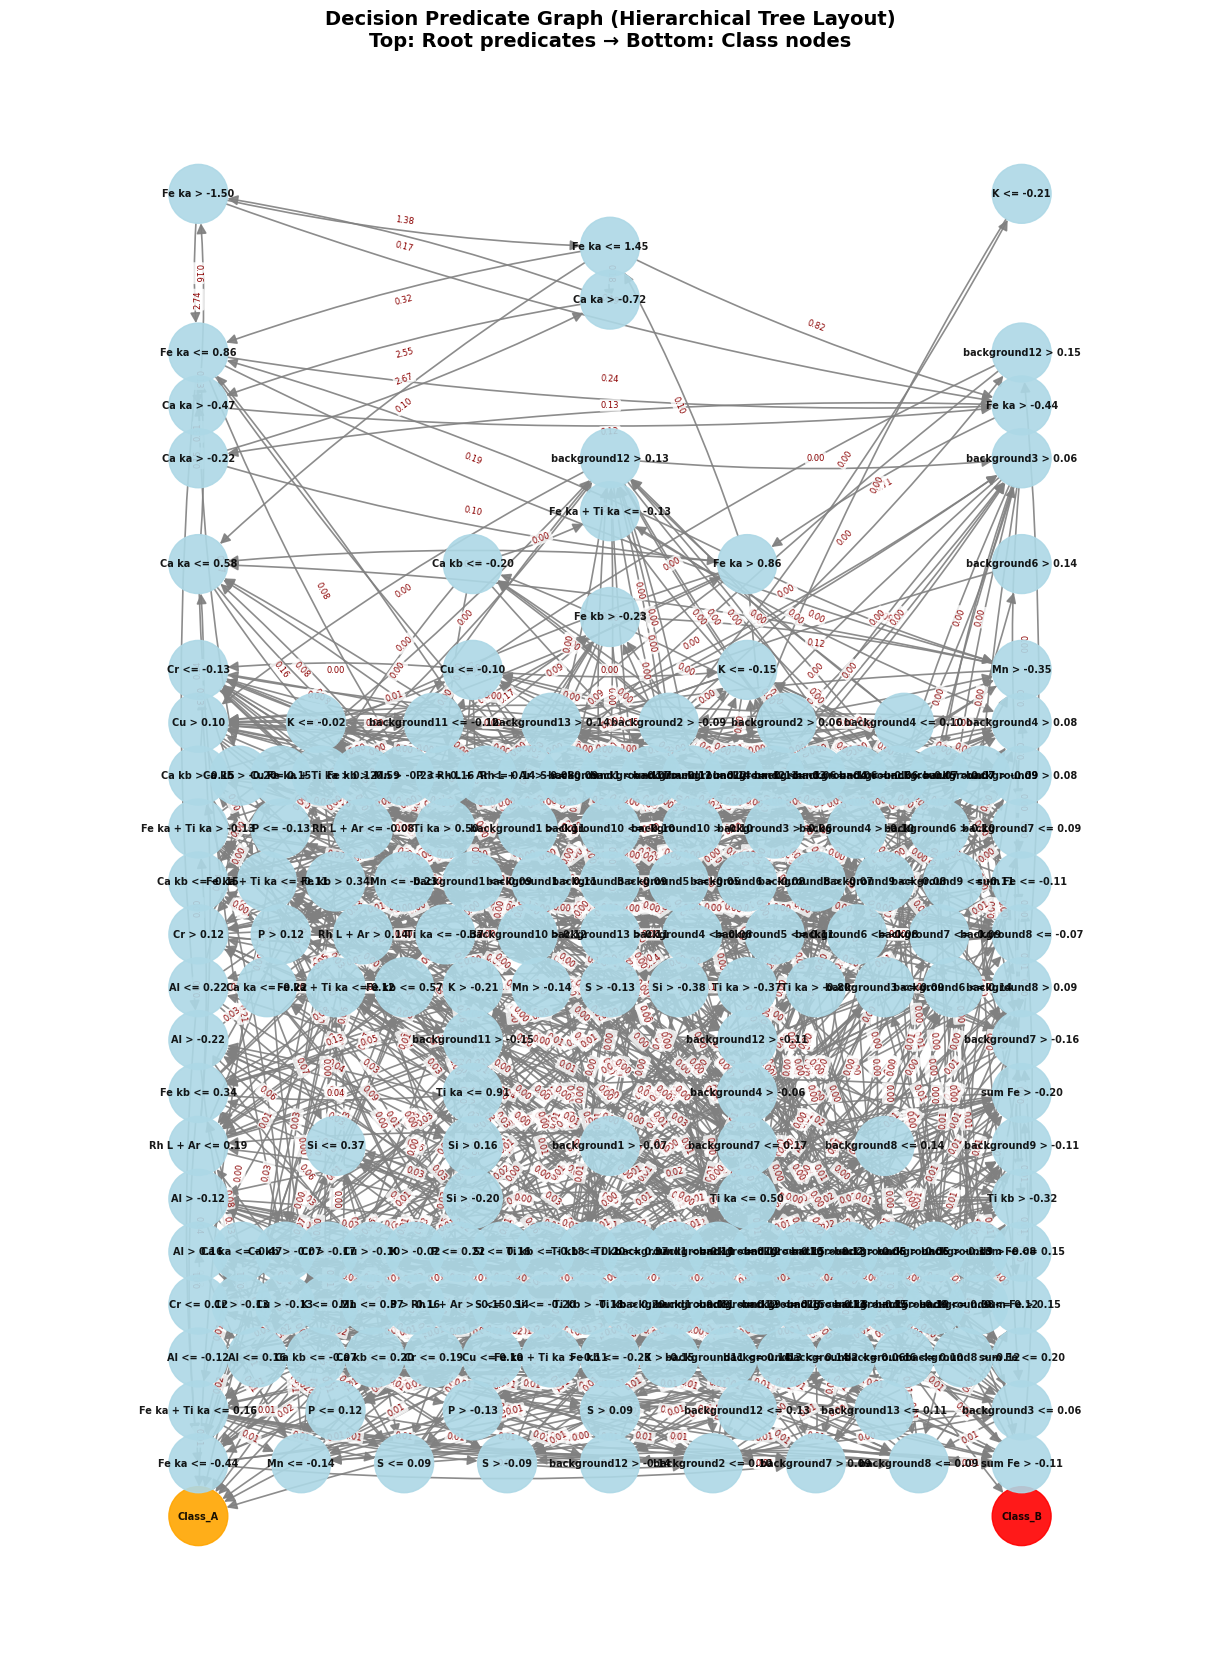

In [26]:
# Plotando o grafo final em estilo de árvore hierárquica
import matplotlib.pyplot as plt
import networkx as nx

DG = graphs_by_seed[random_seeds[0]]  # usando o grafo da primeira semente como exemplo

# Função para criar layout hierárquico (árvore de cima para baixo)
def hierarchical_layout(G, root_nodes=None, width=0.5, vert_gap=1.5, vert_loc=0, xcenter=0.5):
    """
    Cria um layout hierárquico para um grafo direcionado.
    Nós com menos conexões (raízes) ficam no topo, nós terminais na base.
    """
    pos = {}
    
    # Identificar nós terminais (Class_A, Class_B)
    terminal_nodes = [n for n, attr in G.nodes(data=True) if attr.get('node_type') == 'terminal']
    
    # Identificar nós raiz (sem predecessores ou com menos conexões de entrada)
    if root_nodes is None:
        # Nós sem predecessores são potenciais raízes
        root_nodes = [n for n in G.nodes() if G.in_degree(n) == 0 and n not in terminal_nodes]
        # Se não há raízes claras, usar nós com menor grau de entrada
        if not root_nodes:
            non_terminal = [n for n in G.nodes() if n not in terminal_nodes]
            if non_terminal:
                min_in_degree = min(G.in_degree(n) for n in non_terminal)
                root_nodes = [n for n in non_terminal if G.in_degree(n) == min_in_degree]
    
    # Calcular níveis usando BFS a partir das raízes
    levels = {}
    
    # Primeiro, atribuir nível 0 às raízes
    for root in root_nodes:
        levels[root] = 0
    
    # BFS para atribuir níveis aos outros nós
    visited = set(root_nodes)
    queue = list(root_nodes)
    
    while queue:
        node = queue.pop(0)
        current_level = levels[node]
        for successor in G.successors(node):
            if successor not in visited:
                levels[successor] = current_level + 1
                visited.add(successor)
                queue.append(successor)
            elif successor in levels:
                # Atualizar para o maior nível se já visitado
                levels[successor] = max(levels[successor], current_level + 1)
    
    # Atribuir nível máximo aos terminais
    if levels:
        max_level = max(levels.values()) + 1
    else:
        max_level = 1
    
    for terminal in terminal_nodes:
        levels[terminal] = max_level
    
    # Nós não visitados recebem nível intermediário
    for node in G.nodes():
        if node not in levels:
            levels[node] = max_level // 2
    
    # Agrupar nós por nível
    nodes_by_level = {}
    for node, level in levels.items():
        if level not in nodes_by_level:
            nodes_by_level[level] = []
        nodes_by_level[level].append(node)
    
    # Calcular posições
    max_level = max(nodes_by_level.keys())
    
    for level, nodes in nodes_by_level.items():
        n_nodes = len(nodes)
        # Distribuir nós horizontalmente
        if n_nodes == 1:
            x_positions = [xcenter]
        else:
            x_positions = [xcenter - width/2 + i * width / (n_nodes - 1) for i in range(n_nodes)]
        
        # Posição vertical (nível 0 no topo, níveis maiores embaixo)
        y = vert_loc - level * vert_gap
        
        for i, node in enumerate(sorted(nodes)):
            pos[node] = (x_positions[i], y)
    
    return pos

# Criar layout hierárquico com maior dispersão vertical e horizontal
pos = hierarchical_layout(DG, width=4.0, vert_gap=1.5)

# Cores dos nós
colors = []
for node in DG.nodes():
    node_type = DG.nodes[node].get('node_type', 'predicate')
    if node_type == 'root_predicate':
        colors.append('green')
    elif node_type == 'terminal':
        colors.append('orange' if DG.nodes[node].get('class_label') == 'A' else 'red')
    else:
        colors.append('lightblue')

# Preparar labels das arestas (pesos)
edge_labels = {(u, v): f"{DG[u][v]['weight']:.2f}" for u, v in DG.edges()}

# Plotando com figura maior para acomodar a dispersão
plt.figure(figsize=(12, 16))
nx.draw(DG, pos, 
        node_color=colors,
        node_size=1800,
        with_labels=True,
        font_size=7,
        font_weight='bold',
        arrows=True,
        arrowsize=15,
        edge_color='gray',
        width=1.2,
        alpha=0.9,
        arrowstyle='-|>',
        connectionstyle='arc3,rad=0.05')

# Adicionar labels dos pesos nas arestas
nx.draw_networkx_edge_labels(DG, pos, 
                              edge_labels=edge_labels, 
                              font_size=6, 
                              font_color='darkred',
                              bbox=dict(boxstyle='round,pad=0.2', 
                                       facecolor='white', 
                                       edgecolor='none', 
                                       alpha=0.8))

plt.title('Decision Predicate Graph (Hierarchical Tree Layout)\nTop: Root predicates → Bottom: Class nodes',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.axis('off')
plt.show()

In [12]:
import explaining as exp

# LISTA DE SEMENTES A TESTAR
random_seeds = [0, 1]

all_results_pert = {}
training_samples = len(Xcalclass)

# LOOP: PROCESSAR CADA SEMENTE
y_predicted_numeric = plsda_results[5].iloc[:, -1] # predições numéricas do modelo

for seed in random_seeds:
    print(f"\n{'='*70}")
    print(f"Processando semente: {seed}")
    print(f"{'='*70}\n")
    # Bagging
    bags_result_seed = exp.bagging_predicates(
        zone_sums_df=zone_sums_df,
        y_predicted_numeric=y_predicted_numeric,
        predicates_df=predicates_quantiles[0],
        n_bags=10,
        #n_predicates_per_bag=40,
        n_samples_per_bag=int(training_samples*0.8), # 80 % da base para amostrar (convertido para int)
        min_samples_per_predicate=int(training_samples*0.1), # 20 % da base para limitar (convertido para int)
        replace=False,
        sample_bagging=True,
        predicate_bagging=False,
        random_seed=seed
    )
    # Inserir classe prevista
    for bag_name, pred_dict in bags_result_seed.items(): # iterando sobre cada bag
        for pred_rule, df_info in pred_dict.items():
            df_info['Class_Predicted'] = np.where(df_info['Predicted_Y'] >= 0.5, 'A', 'B') # binarizando com threshold 0.5, A = eut, B = dist

    pert_results_seed = exp.calculate_predicate_perturbation(
        estimator=pls_model,
        Xcalclass_prep=Xcalclass_prep,
        folds_struct=bags_result_seed,
        predicates_df=predicates_quantiles[0],
        spectral_cuts=spectral_cuts,
        #perturbation_value=0,
        perturbation_mode='mean', # valores entre 'mean' ou 'min'
        stats_source='full', # full indica usar todas as amostras para calcular estatísticas enquanto que 'fold' usa apenas as amostras do fold atual
        metric='mean_abs_diff',   # Média com sinal (pode ser negativo)
        verbose=True
    )

    # Remove todos os valores iguais a zero de todos os bags em perm_results[bag]["Permutation"] e salva como perm_results_thresholded
    # pert_results_seed_thresholded = {}
    # for bag, df in perm_results_seed.items():
    #     # Verifica se é um DataFrame e se a coluna 'Permutation' existe
    #     if isinstance(df, pd.DataFrame) and 'Permutation' in df.columns:
    #         filtered_df = df[df['Permutation'] > 0].copy()
    #         pert_results_seed_thresholded[bag] = filtered_df
    #     else:
    #         # Se não for DataFrame esperado, apenas copia
    #         pert_results_seed_thresholded[bag] = df

    # Salvar no dicionário principal
    all_results_pert[seed] = {
        'bags_result': bags_result_seed,
        'pert_results_dict': pert_results_seed
    }

# CONSTRUÇÃO DE GRAFOS PARA MÚLTIPLAS SEMENTES (LOOP EXTERNO)
# Dicionário para armazenar grafos
graphs_pert_by_seed = {}

for seed in random_seeds:
    print(f"\n{'='*70}")
    print(f"Processando Grafo - Semente: {seed}")
    print(f"{'='*70}\n")
    # Construir grafo para esta semente
    DG = build_predicate_graphv2(
        bags_result=all_results_cov[seed]['bags_result'],
        mi_results_dict=all_results_pert[seed]['pert_results_dict'],
        metric_column='Perturbation',  # ou 'Covariance' se mudar a métrica
        random_state=seed,
        show_details=True
    )

    # Armazenar grafo
    graphs_pert_by_seed[seed] = DG  

# Calcular LRC usando a função pronta do explaining.py
lrc_pert_by_seed = {}
for seed in random_seeds:
    DG = graphs_pert_by_seed[seed]
    lrc_pert_df_seed = exp.calculate_lrc_single_graph(DG, predicates_quantiles[0])
    lrc_pert_df_seed['Seed'] = seed  # Adicionar coluna com a semente
    lrc_pert_by_seed[seed] = lrc_pert_df_seed

# junando todas as colunas 'Node' de lrc_by_seed em um único dataframe
lrc_pert_all_seeds_df = pd.DataFrame()
for seed in random_seeds:
    lrc_pert_df_seed = lrc_pert_by_seed[seed].rename(columns={'Node': f'Predicate_pert_Seed_{seed}'})
    lrc_pert_all_seeds_df = pd.concat([lrc_pert_all_seeds_df, lrc_pert_df_seed[[f'Predicate_pert_Seed_{seed}']]], axis=1)

# vamos filtrar lrc_by_seed em cada semente para manter apenas as zonas espectrais únicas com maior LRC em um mesmo dataframe
lrc_pert_unique_by_seed = {}
for seed, lrc_df in lrc_pert_by_seed.items():
    lrc_pert_unique_df = lrc_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
    lrc_pert_unique_df = lrc_pert_unique_df.sort_values(by='Local_Reaching_Centrality', ascending=False).reset_index(drop=True)
    lrc_pert_unique_by_seed[seed] = lrc_pert_unique_df

lrc_pert_all_seeds_df # exibindo o dataframe consolidado com predicados de todas as sementes


Processando semente: 0

Bag_1 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_2 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_3 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_4 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_5 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_6 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_7 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_8 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_9 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
Bag_10 | Amostras: Sim | Predicados: Não (Todos) | Válidos: 200 | Descartados: 0
PERTURBATION IMPORTANCE PARA PREDICADOS
Modo de perturbação: mean
Fonte das estatísticas: full
Métrica: mean_abs_diff
Total de folds: 10


[Bag_1] Processando 200 predicados.

,Predicate_pert_Seed_0,Predicate_pert_Seed_1
0,Fe ka <= -3.73,Fe ka <= -3.73
1,Fe ka > 4.61,Fe ka > 4.61
2,Fe ka > 2.41,Fe ka > 2.41
3,Fe ka <= -2.42,Fe ka <= -2.42
4,Fe ka <= 4.61,Fe ka > -2.42
...,...,...
197,background1 <= 0.09,background4 <= 0.31
198,background4 <= 0.31,background1 <= 0.09
199,background4 <= 0.08,background4 <= 0.08
200,Class_A,Class_A


In [13]:
all_results_pert[0]['pert_results_dict']['Bag_1']

,Predicate,Perturbation
0,Fe ka > 4.61,0.524302
1,Fe ka <= -3.73,0.523249
2,Fe ka > 2.41,0.441986
3,Fe ka <= -2.42,0.419044
4,Fe ka > -2.42,0.344605
...,...,...
195,background4 > -0.26,0.000030
196,background4 <= 0.31,0.000030
197,background4 <= 0.08,0.000029
198,background1 <= 0.12,0.000029


In [14]:
# Somar LRCs de predicados equivalentes entre diferentes seeds
lrc_combined_list = []

for seed in random_seeds:
    lrc_df = lrc_pert_by_seed[seed].copy()
    lrc_combined_list.append(lrc_df)

# Concatenar todos os dataframes
lrc_all_seeds = pd.concat(lrc_combined_list, ignore_index=True)

# Agrupar por predicado (Node) e somar as LRCs, mantendo Zone, Threshold e Operator
lrc_summed_df = lrc_all_seeds.groupby('Node').agg({
    'Local_Reaching_Centrality': 'sum',
    'Zone': 'first',
    'Threshold': 'first',
    'Operator': 'first'
}).reset_index()

# Ordenar pelo valor de LRC somado (maior para menor)
lrc_summed_df = lrc_summed_df.sort_values(by='Local_Reaching_Centrality', ascending=False).reset_index(drop=True)

lrc_summed_df

,Node,Local_Reaching_Centrality,Zone,Threshold,Operator
0,Fe ka <= -3.73,19.840101,Fe ka,-3.73,<=
1,Fe ka > 4.61,17.259179,Fe ka,4.61,>
2,Fe ka > 2.41,14.543031,Fe ka,2.41,>
3,Fe ka <= -2.42,11.536563,Fe ka,-2.42,<=
4,Fe ka > -2.42,9.346523,Fe ka,-2.42,>
...,...,...,...,...,...
197,background4 <= 0.31,0.000061,background4,0.31,<=
198,background1 <= 0.09,0.000058,background1,0.09,<=
199,background4 <= 0.08,0.000042,background4,0.08,<=
200,Class_B,0.000000,None,None,None


In [15]:
# vamoss pegar so os valore sunicos de lrc_summed_df baseado na zona espectral
lrc_summed_unique_df_pert = lrc_summed_df.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
lrc_summed_unique_df_pert = lrc_summed_unique_df_pert.sort_values(by='Local_Reaching_Centrality', ascending=False).reset_index(drop=True)
lrc_summed_unique_df_pert

,Node,Local_Reaching_Centrality,Zone,Threshold,Operator
0,Fe ka <= -3.73,19.840101,Fe ka,-3.73,<=
1,Ca ka > 0.76,4.050840,Ca ka,0.76,>
2,Ti ka <= -0.84,3.638252,Ti ka,-0.84,<=
3,Fe kb <= -1.37,3.158488,Fe kb,-1.37,<=
4,Mn > 0.47,1.055710,Mn,0.47,>
5,background6 > 0.18,0.353637,background6,0.18,>
6,Ti kb <= -0.42,0.327930,Ti kb,-0.42,<=
7,Al > 0.29,0.305675,Al,0.29,>
8,sum Fe > 0.51,0.304608,sum Fe,0.51,>
9,Rh L + Ar > 0.36,0.287725,Rh L + Ar,0.36,>


C:\Users\Usuario\AppData\Local\Temp\ipykernel_14656\2828822795.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


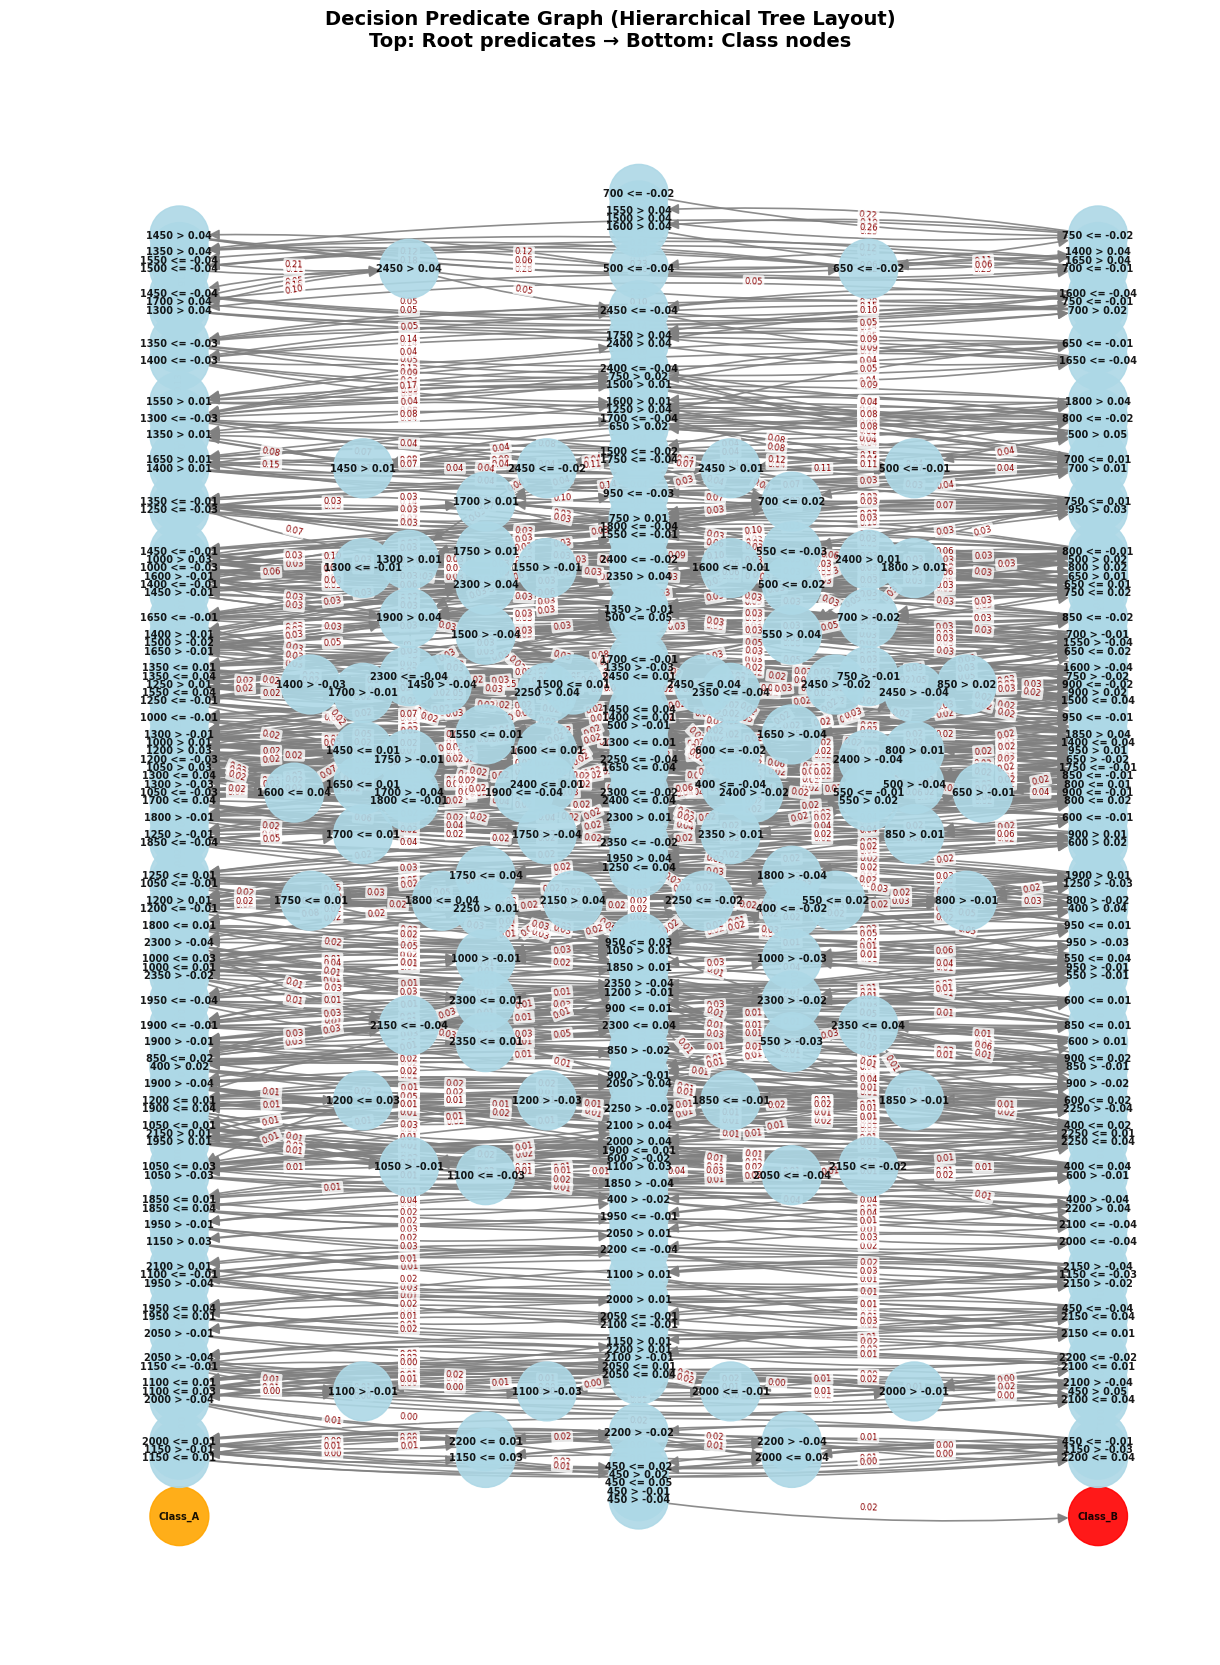

In [37]:
# Plotando o grafo final em estilo de árvore hierárquica
import matplotlib.pyplot as plt
import networkx as nx

DG = graphs_pert_by_seed[random_seeds[0]]  # usando o grafo da primeira semente como exemplo

# Função para criar layout hierárquico (árvore de cima para baixo)
def hierarchical_layout(G, root_nodes=None, width=0.5, vert_gap=1.5, vert_loc=0, xcenter=0.5):
    """
    Cria um layout hierárquico para um grafo direcionado.
    Nós com menos conexões (raízes) ficam no topo, nós terminais na base.
    """
    pos = {}
    
    # Identificar nós terminais (Class_A, Class_B)
    terminal_nodes = [n for n, attr in G.nodes(data=True) if attr.get('node_type') == 'terminal']
    
    # Identificar nós raiz (sem predecessores ou com menos conexões de entrada)
    if root_nodes is None:
        # Nós sem predecessores são potenciais raízes
        root_nodes = [n for n in G.nodes() if G.in_degree(n) == 0 and n not in terminal_nodes]
        # Se não há raízes claras, usar nós com menor grau de entrada
        if not root_nodes:
            non_terminal = [n for n in G.nodes() if n not in terminal_nodes]
            if non_terminal:
                min_in_degree = min(G.in_degree(n) for n in non_terminal)
                root_nodes = [n for n in non_terminal if G.in_degree(n) == min_in_degree]
    
    # Calcular níveis usando BFS a partir das raízes
    levels = {}
    
    # Primeiro, atribuir nível 0 às raízes
    for root in root_nodes:
        levels[root] = 0
    
    # BFS para atribuir níveis aos outros nós
    visited = set(root_nodes)
    queue = list(root_nodes)
    
    while queue:
        node = queue.pop(0)
        current_level = levels[node]
        for successor in G.successors(node):
            if successor not in visited:
                levels[successor] = current_level + 1
                visited.add(successor)
                queue.append(successor)
            elif successor in levels:
                # Atualizar para o maior nível se já visitado
                levels[successor] = max(levels[successor], current_level + 1)
    
    # Atribuir nível máximo aos terminais
    if levels:
        max_level = max(levels.values()) + 1
    else:
        max_level = 1
    
    for terminal in terminal_nodes:
        levels[terminal] = max_level
    
    # Nós não visitados recebem nível intermediário
    for node in G.nodes():
        if node not in levels:
            levels[node] = max_level // 2
    
    # Agrupar nós por nível
    nodes_by_level = {}
    for node, level in levels.items():
        if level not in nodes_by_level:
            nodes_by_level[level] = []
        nodes_by_level[level].append(node)
    
    # Calcular posições
    max_level = max(nodes_by_level.keys())
    
    for level, nodes in nodes_by_level.items():
        n_nodes = len(nodes)
        # Distribuir nós horizontalmente
        if n_nodes == 1:
            x_positions = [xcenter]
        else:
            x_positions = [xcenter - width/2 + i * width / (n_nodes - 1) for i in range(n_nodes)]
        
        # Posição vertical (nível 0 no topo, níveis maiores embaixo)
        y = vert_loc - level * vert_gap
        
        for i, node in enumerate(sorted(nodes)):
            pos[node] = (x_positions[i], y)
    
    return pos

# Criar layout hierárquico com maior dispersão vertical e horizontal
pos = hierarchical_layout(DG, width=4.0, vert_gap=1.5)

# Cores dos nós
colors = []
for node in DG.nodes():
    node_type = DG.nodes[node].get('node_type', 'predicate')
    if node_type == 'root_predicate':
        colors.append('green')
    elif node_type == 'terminal':
        colors.append('orange' if DG.nodes[node].get('class_label') == 'A' else 'red')
    else:
        colors.append('lightblue')

# Preparar labels das arestas (pesos)
edge_labels = {(u, v): f"{DG[u][v]['weight']:.2f}" for u, v in DG.edges()}

# Plotando com figura maior para acomodar a dispersão
plt.figure(figsize=(12, 16))
nx.draw(DG, pos, 
        node_color=colors,
        node_size=1800,
        with_labels=True,
        font_size=7,
        font_weight='bold',
        arrows=True,
        arrowsize=15,
        edge_color='gray',
        width=1.2,
        alpha=0.9,
        arrowstyle='-|>',
        connectionstyle='arc3,rad=0.05')

# Adicionar labels dos pesos nas arestas
nx.draw_networkx_edge_labels(DG, pos, 
                              edge_labels=edge_labels, 
                              font_size=6, 
                              font_color='darkred',
                              bbox=dict(boxstyle='round,pad=0.2', 
                                       facecolor='white', 
                                       edgecolor='none', 
                                       alpha=0.8))

plt.title('Decision Predicate Graph (Hierarchical Tree Layout)\nTop: Root predicates → Bottom: Class nodes',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.axis('off')
plt.show()

In [16]:
reg_vet = pd.DataFrame(plsda_results[3].coef_, columns=plsda_results[3].feature_names_in_) # creating a DataFrame with regression coefficients
reg_vet = reg_vet.T
reg_vet.insert(0, 'energy', reg_vet.index) # adding energy column
reg_vet = reg_vet.reset_index(drop=True)
reg_vet.columns = ['energy', 'Reg_coef'] # renaming
reg_vet['Abs_Reg_coef'] = reg_vet['Reg_coef'].abs() # adding absolute value column
reg_vet = reg_vet.sort_values(by='Abs_Reg_coef', ascending=False).reset_index(drop=True) # sorting by absolute value

# gerando uma nova coluna em reg_vet com o nome da zona espectral correspondente de acordo com a lista spectral_cuts
energy_to_zone_reg = {} # dicionário para mapear energia para zona espectral
for zone_name, start, end in spectral_cuts: # iterando sobre cada zona espectral (que tem nome, início e fim)
    for i in reg_vet['energy']: # iterando sobre cada valor de energia no reg_vet
        i_float = float(i)
        if start <= i_float <= end:
            energy_to_zone_reg[i] = zone_name
reg_vet['Zone'] = reg_vet['energy'].map(energy_to_zone_reg) # a funcao map funciona como um buscador que substitui os valores de 'energy' pelos valores correspondentes no dicionário energy_to_zone_reg
reg_vet

# vamos filtrar reg_vet para manter apenas as zonas espectrais únicas com maior valor absoluto do coeficiente de regressão
reg_vet_unique_df = reg_vet.drop_duplicates(subset=['Zone'], keep='first').reset_index(drop=True)
reg_vet_unique_df = reg_vet_unique_df.sort_values(by='Abs_Reg_coef', ascending=False).reset_index(drop=True)
reg_vet_unique_df

,energy,Reg_coef,Abs_Reg_coef,Zone
0,6.38,-0.015276,0.015276,Fe ka
1,3.7,-0.011133,0.011133,Ca ka
2,4.52,0.010570,0.010570,Ti ka
3,7.04,-0.005185,0.005185,Fe kb
4,5.9,-0.005023,0.005023,Mn
5,1.48,0.004194,0.004194,Al
6,2.6,-0.002794,0.002794,Rh L + Ar
7,4.02,-0.002689,0.002689,Ca kb
8,3.32,-0.002262,0.002262,K
9,4.88,0.002194,0.002194,Ti kb


In [19]:
import numpy as np

max_len = max(
    len(vip_scores_unique_df['Zone']),
    len(reg_vet_unique_df['Zone']),
    len(lrc_summed_unique_df_cov['Zone']),
    len(lrc_summed_unique_df_pert['Zone'])
)

def pad_list(lst, length):
    return list(lst) + [None] * (length - len(lst))

features_importance = pd.DataFrame({
    'Vip': pad_list(vip_scores_unique_df['Zone'], max_len),
    'Reg_coef': pad_list(reg_vet_unique_df['Zone'], max_len),
    'LRC_cov' : pad_list(lrc_summed_unique_df_cov['Zone'], max_len),
    'LRC_pert' : pad_list(lrc_summed_unique_df_pert['Zone'], max_len),
})
features_importance

,Vip,Reg_coef,LRC_cov,LRC_pert
0,Fe ka,Fe ka,Fe ka,Fe ka
1,Fe kb,Ca ka,Fe kb,Ca ka
2,Ti ka,Ti ka,Mn,Ti ka
3,Ca ka,Fe kb,sum Fe,Fe kb
4,Mn,Mn,Ca ka,Mn
5,sum Fe,Al,Ti ka,background6
6,Ti kb,Rh L + Ar,background4,Ti kb
7,Al,Ca kb,Si,Al
8,Si,K,Cr,sum Fe
9,background4,Ti kb,Ti kb,Rh L + Ar


In [20]:
# RBO (Rank-Biased Overlap) para comparar rankings
import rbo
rbo_results = {}
reference_list = [x for x in features_importance['Vip'].tolist() if x is not None]
methods = ['Reg_coef', 'LRC_cov', 'LRC_pert']
for method in methods:
    compare_list = [x for x in features_importance[method].tolist() if x is not None]
    # Truncate both lists to the same length (minimum of both)
    min_len = min(len(reference_list), len(compare_list))
    ref_trunc = reference_list[:min_len]
    cmp_trunc = compare_list[:min_len]
    score = rbo.RankingSimilarity(ref_trunc, cmp_trunc).rbo(p=0.7, k=10)
    rbo_results[method] = score
rbo_results = pd.DataFrame(list(rbo_results.items()), columns=['Method','RBO_Score'])
rbo_results.insert(0, 'Reference', 'Vip')
rbo_results.sort_values(by='RBO_Score', ascending=False, inplace=True)
#rbo_results.to_csv('rbo_rank.csv', index=False, sep=';')
rbo_results

,Reference,Method,RBO_Score
1,Vip,LRC_cov,0.840624
2,Vip,LRC_pert,0.796876
0,Vip,Reg_coef,0.783692


In [21]:
# calculando a mutual information relacionando cada variável espectral com a predição do modelo PLS-DA
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
global_mi_scores = mutual_info_regression(Xcalclass_prep, 
                                    plsda_results[5].iloc[:,-1], # using the continuous predictions from LV=3
                                    discrete_features=False,
                                    n_neighbors=100)
global_mi_scores_df = pd.DataFrame(global_mi_scores, index=Xcalclass_prep.columns, columns=['MI Score'])#.sort_values(by='MI Score', ascending=False)
global_mi_scores_df.plot()


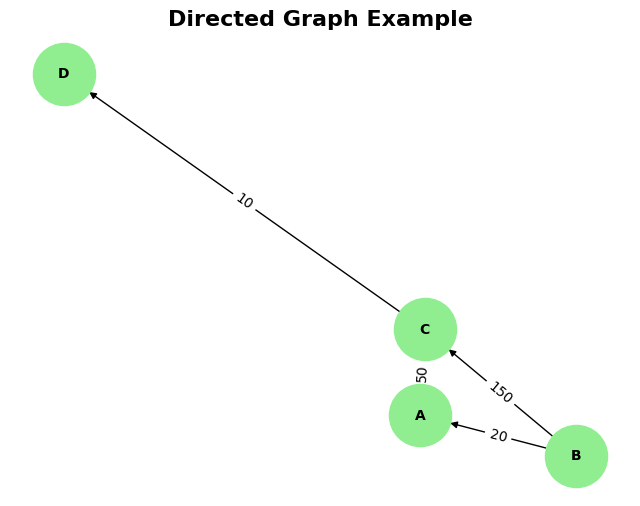

In [24]:
import networkx as nx
DG = nx.DiGraph()
DG.add_node("A")
DG.add_node("B")
DG.add_node("C")
DG.add_node("D")
DG.add_edge("B", "A", weight=20)
DG.add_edge("B", "C", weight=150)
DG.add_edge("A", "C", weight=50)
DG.add_edge("C", "D", weight=10)
 #plotar o grafo direcionado
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
pos = nx.spring_layout(DG, seed=42)
nx.draw(DG, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_size=10, font_weight='bold', arrows=True)
edge_labels = nx.get_edge_attributes(DG, 'weight')
nx.draw_networkx_edge_labels(DG, pos, edge_labels=edge_labels)
plt.title('Directed Graph Example', fontsize=16, fontweight='bold')
plt.show()

In [34]:
nx.local_reaching_centrality(DG, normalized=True, v='B', weight='weight')

1.4492753623188406